<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
<a href="http://mng.bz/orYv">《从零构建大语言模型》</a>一书的配套代码，作者：<a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>代码仓库：<a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp?1" width="100px"></a>
</td>
</tr>
</table>

# 第八章：蒸馏推理模型以实现高效推理

本笔记本中正在使用的包：

In [1]:
from importlib.metadata import version

used_libraries = [
    "reasoning_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

reasoning_from_scratch version: 0.1.17
torch version: 2.10.0
tokenizers version: 0.21.4


<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F01_raschka.webp" width=600>

&nbsp;
## 8.1 面向推理任务的模型蒸馏简介

- 蒸馏是指用一个大型语言模型（"教师"）的输出来训练一个较小的语言模型（"学生"）
- 蒸馏可能比从头开始使用 RLVR 训练更有效
  - 例如，[DeepSeek-R1 论文](https://arxiv.org/abs/2501.12948) 报告称，对于较小的 DeepSeek-R1 模型变体，通过蒸馏能够实现比 RLVR 更好的性能
  - 具体而言，他们先训练了最大的 DeepSeek R1 模型（6710 亿参数），然后用它通过蒸馏来训练较小的模型

- 蒸馏主要有两种类型：硬蒸馏和软蒸馏
  1. 硬蒸馏：学生模型基于教师生成的文本进行训练（教师的输出被视为真实目标）
  2. 软蒸馏：学生模型被训练以匹配教师在词汇表上的概率分布（通常通过最小化教师和学生分布之间的KL散度，这些分布源自它们的对数几率）

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F02_raschka.webp" width=600>

- 1. 纯硬蒸馏：
  - 我们仅使用教师生成的文本作为目标（此处教师输出被视为真实目标）
  - 损失函数：`L = CrossEntropy(y_teacher_tokens, y_student)`
  - 从技术上讲，这是基于合成数据的标准监督微调
  - 无需访问教师logits
  - 这正是DeepSeek-R1蒸馏中较小模型的做法：通过大型671B DeepSeek-R1（教师）生成推理轨迹，并在这些轨迹上微调较小的LLM（学生）

- 2. 纯软蒸馏
  - 我们直接匹配教师的输出概率分布
  - 损失函数：`L = KL(p_teacher || p_student)`
  - 这需要在训练时获取教师logits（或对数概率）

- 3. 结合硬蒸馏与软蒸馏
  - 这是经典的知识蒸馏方法（起源于计算机视觉），详见论文[Distilling the Knowledge in a Neural Network](https://arxiv.org/abs/1503.02531)
  - 我们使用教师模型的实际输出token进行训练，同时强制学生模型匹配教师模型的完整概率分布
  - 损失函数：`L = CE(y_teacher_tokens, y_student) + lambda * KL(p_teacher || p_student)`，其中`lambda`是用于调节KL散度项贡献权重的超参数

- 硬蒸馏在实践中更为常见
  - 通常无法获取对数概率；即 OpenAI ChatGPT 或 Anthropic Claude 等专有系统不会暴露完整的词汇对数概率，这使得传统的软蒸馏无法实现
  - 即使可以获取对数概率，软蒸馏也要求学生和教师大语言模型使用相同的分词方式；否则词汇表将无法匹配（因此，软蒸馏在相同模型家族内使用时更为有效）
  - 需要注意的是，即使是生成并重复使用文本输出进行蒸馏，也可能违反某些服务提供商的政策
  - 即使对数概率可用，为长序列存储完整的词汇分布在带宽和磁盘空间方面成本高昂；生成并存储纯文本输出则要经济得多

- 如果软蒸馏和硬蒸馏都可行，哪种方法表现更好？
  - 设计合理的软蒸馏目标函数可以超越硬蒸馏（https://arxiv.org/abs/2306.08543）
  - 但在现代大语言模型基准测试中，目前尚无近期大规模直接对比研究，其中软蒸馏与硬蒸馏是唯一变量以实现公平比较
  - 数据生成策略可能比监督信号是软性还是硬性更为重要（https://arxiv.org/abs/2306.13649）

- 在本章中，我们实现了类似于 DeepSeek-R1 的硬蒸馏，这是一种更常见且实用的方法。

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F03_raschka.webp" width=600 alt="图 8.3">

&nbsp;
## 8.2 为推理蒸馏生成数据集

- 蒸馏的第一步是为训练学生模型创建数据集（此处指我们在本书中一直使用的Qwen3 0.6B基础模型）
- 我们将使用MATH数据集中与MATH-500测试集不重叠的12,000道数学题（https://github.com/rasbt/math_full_minus_math500）
- 这些正是我们在第6章和第7章中用于RLVR的12,000道数学题
- 我们将这12,000道数学题输入现有的推理模型（此处指DeepSeek-R1），并收集其响应用于训练

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F04_raschka.webp" width=500>

- 在第6章和第7章中，我们使用RLVR训练Qwen3基础模型以生成正确解
- 随后通过验证器将正确解与参考解进行比较，从而计算训练信号
- 在蒸馏过程中，我们将教师模型的解与学生模型的解进行比较以计算训练信号

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F05_raschka.webp" width=600 alt="CH08_F05_raschka">

- 对于我们的蒸馏方法，可以在开始训练学生模型之前，先使用教师模型预先生成蒸馏数据集
- 由于为全部12,000道数学题生成教师答案可能非常耗时且资源密集，我通过OpenRouter托管的6710亿参数DeepSeek-R1模型预先生成了该数据集（生成该数据集的API成本约为50美元）
- 在下一节中，我们将加载这个预先生成的数据集，因此您无需自行生成该数据集
- 不过，如果您感兴趣，可以在补充材料中找到我使用的代码及使用说明：[https://github.com/rasbt/reasoning-from-scratch/tree/main/ch08/02_generate_distillation_data](https://github.com/rasbt/reasoning-from-scratch/tree/main/ch08/02_generate_distillation_data)

&nbsp;
## 8.3 加载用于蒸馏的 MATH 训练数据集

- 在本节中，我们将加载由 DeepSeek-R1 生成的数学问题及答案数据集，具体方法如上一节所述。

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F06_raschka.webp" width=600>

- 该数据集可从Hugging Face模型中心获取：https://huggingface.co/datasets/rasbt/math_distill
- 以下代码将其加载到我们的Python会话中：

In [2]:
import json
import requests
from pathlib import Path


def load_distill_data(
    local_path=None,
    partition="deepseek-r1-math-train",
    save_copy=True,
):

    if local_path is None:
        local_path = f"{partition}.json"
    local_path = Path(local_path)

    url = (
        "https://huggingface.co/datasets/rasbt/math_distill"
        "/resolve/main/data/"
        f"{partition}.json"
    )
    backup_url = (
        "https://f001.backblazeb2.com/file/reasoning-from-scratch/"
        f"MATH/{partition}.json"
    )

    if local_path.exists():
        with local_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        size_kb = local_path.stat().st_size / 1e3
        print(f"{local_path}: {size_kb:.1f} KB (cached)")
        return data

    assert partition in (
        "deepseek-r1-math-train",
        "deepseek-r1-math500",
        "qwen3-235b-a22b-math-train",
        "qwen3-235b-a22b-math500",
    )

    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
    except requests.RequestException:
        print("Using backup URL.")
        r = requests.get(backup_url, timeout=30)
        r.raise_for_status()

    data = r.json()

    if save_copy:
        with local_path.open("w", encoding="utf-8") as f:
            json.dump(data, f, indent=2)

        size_kb = local_path.stat().st_size / 1e3
        print(f"{local_path}: {size_kb:.1f} KB")

    return data

In [3]:
math_train = load_distill_data(partition="deepseek-r1-math-train")

print("Dataset size:", len(math_train))

deepseek-r1-math-train.json: 107538.0 KB (cached)
Dataset size: 12000


让我们查看一个训练样本以检查结构：

In [4]:
from pprint import pprint

pprint(math_train[4])

{'gtruth_answer': '6',
 'message_content': 'Sam worked \\( x \\) days and did not work \\( y \\) '
                    'days. We know:\n'
                    '\\[\n'
                    'x + y = 20\n'
                    '\\]\n'
                    'His total earnings are calculated as:\n'
                    '\\[\n'
                    '60x - 30y = 660\n'
                    '\\]\n'
                    'Substituting \\( x = 20 - y \\) into the earnings '
                    'equation:\n'
                    '\\[\n'
                    '60(20 - y) - 30y = 660\n'
                    '\\]\n'
                    'Simplifying:\n'
                    '\\[\n'
                    '1200 - 60y - 30y = 660 \\\\\n'
                    '1200 - 90y = 660 \\\\\n'
                    '-90y = 660 - 1200 \\\\\n'
                    '-90y = -540 \\\\\n'
                    'y = \\frac{-540}{-90} = 6\n'
                    '\\]\n'
                    'Sam did not work \\(\\boxed{6}\\) days.',
 'message_t

In [5]:
math_train[4].keys()

dict_keys(['problem', 'gtruth_answer', 'message_thinking', 'message_content'])

- 数据集包含四个字段：
  - `gtruth_answer`：正确的参考答案（标准答案）
  - `message_thinking`：模型撰写的推理过程
  - `message_content`：遵循推理过程的最终答案
- 我们可以使用以下代码来格式化答案：

In [6]:
def format_distilled_answer(entry):
    content = str(entry["message_content"]).strip()
    if not content:
        raise ValueError("Missing non-empty 'message_content' field.")

    thinking = str(entry["message_thinking"]).strip()
    return f"<think>{thinking}</think>\n\n{content}"

In [7]:
print(format_distilled_answer(math_train[4]))

<think>Okay, let's see. Sam was hired for 20 days. Each day he works, he earns $60, but if he doesn't work a day, they deduct $30 from his earnings. At the end of the 20 days, he got $660. I need to find out how many days he didn't work.

Hmm, so let me think. Let's break this down. Let's say he worked x days and didn't work y days. So total days x + y = 20. That's straightforward. Now, his earnings. For each day worked, he gets $60, so total earnings from working would be 60x. But for each day he didn't work, they subtract $30. Wait, how exactly does that subtraction work? Is it that he loses $30 per day not worked from his total earnings?

Wait, maybe. So if he didn't work y days, then he loses 30*y dollars. But wait, does he get a base salary and then deductions? Or is his total earnings 60x minus 30y?

The problem says, "On days that he works, he earns $60. For each day that he does not work, $30 is subtracted from his earnings." So probably, his total earnings are calculated by 60

`必须保留原样不翻译，OpenAI和ChatGPT作为专有名词要保持英文。技术术语"reasoning trace"考虑译为"推理过程"，"parse out"译为"解析出"比较符合中文技术文档习惯。

段落结构上原文是三个并列要点，中文也保持相同的列表格式。第一句的"as discussed"处理为"如前所述"比较简洁。最后一句的"make it easier to"用"可以更方便地"来体现技术文档的客观语气。

整体采用简洁的技术文档风格，避免添加任何解释性内容，严格对应原文信息密度。</think>- 如前所述，`</think>`标记并非必需
- 它们可用于将推理过程与最终答案分离
- 部分服务提供商和界面（如OpenAI的ChatGPT）会向用户隐藏推理过程，通过使用并教导模型使用`

- 如果您好奇DeepSeek-R1模型在此数据集上的准确率表现，由于数据集包含真实标签，我们可以使用第3章的验证器来计算准确率
- 为方便起见，我们可以使用补充材料（第3章）中的[evaluate_json.py](https://github.com/rasbt/reasoning-from-scratch/blob/main/ch03/02_math500-verifier-scripts/evaluate_json.py)脚本直接从JSON文件计算准确率

In [8]:
from reasoning_from_scratch.ch07 import download_from_github

_ = download_from_github(
    "ch03/02_math500-verifier-scripts/evaluate_json.py"
)

evaluate_json.py: 3.3 KB (cached)


In [9]:
!uv run evaluate_json.py \
--json_path "deepseek-r1-math-train.json" \
--gtruth_answer gtruth_answer \
--generated_text message_content

Accuracy: 90.6% (10871/12000)


&nbsp;
## 8.4 构建训练样本

- 在本节中，我们准备用于训练的数据集示例

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F07_raschka.webp" width=600>

- 这项准备工作主要涉及示例的格式化和分词处理
- 在RLVR中，我们采用即时处理方式，因为每个训练示例仅使用一次
- 蒸馏作为一种监督微调形式，受益于对相同示例的多次学习
- 因此，为避免重复劳动，我们一次性完成样本的格式化和分词处理，并将其存储以供重复使用

&nbsp;
### 8.4.1 加载与理解分词器

` should remain unchanged as per the rules. The reference to "chapter 7" should be translated as "第7章" to maintain consistency. 

The structure should remain as bullet points, and the translation should be concise and precise. No additional explanations are needed, just the translated markdown.</think>- 我们从分词器开始
- 我们使用"推理"变体，因为它支持 `...</think>` 标记，如第7章所述

In [10]:
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Tokenizer
)

def load_reasoning_tokenizer(local_dir="qwen3"):
    download_qwen3_small(
        kind="reasoning", tokenizer_only=True, out_dir=local_dir
    )

    tokenizer_path = Path(local_dir) / "tokenizer-reasoning.json"
    tokenizer = Qwen3Tokenizer(
        tokenizer_file_path=tokenizer_path,
        apply_chat_template=True,
        add_generation_prompt=True,
        add_thinking=True,
    )
    
    return tokenizer


tokenizer = load_reasoning_tokenizer()

✓ qwen3/tokenizer-reasoning.json already up-to-date


- 请注意，我们设置了 `apply_chat_template=True` 和 `add_generation_prompt=True`，这将对提示词应用额外的格式化，如下所示：

In [11]:
prompt = "Sam is hired for a 20-day period..."

prompt_ids = tokenizer.encode(prompt)
decoded_prompt = tokenizer.decode(prompt_ids)
print(decoded_prompt)

<|im_start|>user
Sam is hired for a 20-day period...<|im_end|>
<|im_start|>assistant



- 这里，`user` 作为用户输入提示的起始标记
- `

In [12]:
answer = (
    "<think>Okay, let me try to solve "
    "this problem...</think> \\boxed{4}"
)
answer_ids = tokenizer.encode(answer, chat_wrapped=False)
decoded_answer = tokenizer.decode(answer_ids)
print(decoded_answer)

<think>Okay, let me try to solve this problem...</think> \boxed{4}


- For training, we need the combined token IDs including an `<|im_end|>` end-of-sequence token at the end of the answer:

In [13]:
token_ids = prompt_ids + answer_ids + [tokenizer.eos_token_id]
decoded_token_ids = tokenizer.decode(token_ids)
print(decoded_token_ids)

<|im_start|>user
Sam is hired for a 20-day period...<|im_end|>
<|im_start|>assistant
<think>Okay, let me try to solve this problem...</think> \boxed{4}<|im_end|>


- 再次强调，我们使用推理分词器处理 `` 和 `</think>` 标记，但这并不关键；使用基础分词器同样可行
- 聊天模板也是可选的；我们保留它仅因为这是 Qwen3 自身推理模型采用的格式（仅在处理智能体或多提示词场景时需要关注）
- 需要记得在评估脚本中使用 `--which_model "reasoning"` 参数以确保一致性

&nbsp;
### 8.4.2 数据集的格式化与分词化

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F08_raschka.webp" width=400>

- 下面，我们开发一个 `build_examples` 函数，它将对整个数据集应用所需的格式化处理。

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F09_raschka.webp" width=600>

In [14]:
from reasoning_from_scratch.ch03 import render_prompt

def build_examples(data, tokenizer):
    examples = []
    skipped = 0

    for entry in data:
        try:
            # Step 1: encode prompt
            prompt = render_prompt(entry["problem"])
            prompt_ids = tokenizer.encode(prompt)

            # Step 2: encode answer
            target_answer = format_distilled_answer(entry)
            answer_ids = tokenizer.encode(
                target_answer, chat_wrapped=False
            )

            # Step 3: Combine prompt and answer
            token_ids = (
                prompt_ids + answer_ids + [tokenizer.eos_token_id]
            )

            if len(token_ids) < 2:
                skipped += 1
                continue

            examples.append({
                "token_ids": token_ids,
                "prompt_len": len(prompt_ids),
            })
        except (KeyError, TypeError, ValueError):
            skipped += 1

    return examples, skipped

In [15]:
examples, skipped = build_examples(math_train, tokenizer)

print("Number of examples:", len(examples))
print("Number of skipped examples:", skipped)

Number of examples: 12000
Number of skipped examples: 0


In [16]:
print(tokenizer.decode(examples[4]["token_ids"]))

<|im_start|>user
You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Sam is hired for a 20-day period. On days that he works, he earns $\$$60. For each day that he does not work, $\$$30 is subtracted from his earnings. At the end of the 20-day period, he received $\$$660. How many days did he not work?

Answer:<|im_end|>
<|im_start|>assistant
<think>Okay, let's see. Sam was hired for 20 days. Each day he works, he earns $60, but if he doesn't work a day, they deduct $30 from his earnings. At the end of the 20 days, he got $660. I need to find out how many days he didn't work.

Hmm, so let me think. Let's break this down. Let's say he worked x days and didn't work y days. So total days x + y = 20. That's straightforward. Now, his earnings. For each day worked, he gets $60, so total earnings from working would be 60x. But for each day he didn't work, they subtract $30. Wait, how exactly does that subtraction work? I

&nbsp;
### 8.4.3 过滤与划分数据集

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F10_raschka.webp" width=400>

In [17]:
def compute_length(examples, answer_only=False):
    lengths = []
    for ex in examples:
        total = len(ex["token_ids"])
        length = total - ex["prompt_len"] if answer_only else total
        lengths.append(length)

    avg_len = round(sum(lengths) / len(lengths))

    shortest_len = min(lengths)
    longest_len = max(lengths)
    shortest_idx = lengths.index(shortest_len)
    longest_idx = lengths.index(longest_len)

    print(f"Average: {avg_len} tokens")
    print(f"Shortest: {shortest_len} tokens (index {shortest_idx})")
    print(f"Longest: {longest_len} tokens (index {longest_idx})")

compute_length(examples)

Average: 2946 tokens
Shortest: 236 tokens (index 10846)
Longest: 42005 tokens (index 2529)


In [18]:
def filter_examples_by_max_len(examples, max_len=2048):
    filtered_examples = [
        s for s in examples
        if len(s["token_ids"]) <= max_len
    ]

    print("Original:", len(examples))
    print("Filtered:", len(filtered_examples))
    print("Removed:", len(examples) - len(filtered_examples))

    return filtered_examples

filtered_examples = filter_examples_by_max_len(examples, max_len=2048)

Original: 12000
Filtered: 6695
Removed: 5305


In [19]:
compute_length(filtered_examples)

Average: 1180 tokens
Shortest: 236 tokens (index 5971)
Longest: 2048 tokens (index 5587)


In [20]:
import random

rng = random.Random(123)
rng.shuffle(filtered_examples)

train_examples = filtered_examples[25:]
val_examples = filtered_examples[:25]

In [21]:
print("Number of train examples:", len(train_examples))
print("Number of validation examples:", len(val_examples))

Number of train examples: 6670
Number of validation examples: 25


- 练习：检查训练集和验证集的长度以确保它们是平衡的

In [22]:
compute_length(train_examples)

Average: 1180 tokens
Shortest: 236 tokens (index 5730)
Longest: 2048 tokens (index 1319)


In [23]:
compute_length(val_examples)

Average: 1106 tokens
Shortest: 481 tokens (index 15)
Longest: 1918 tokens (index 12)


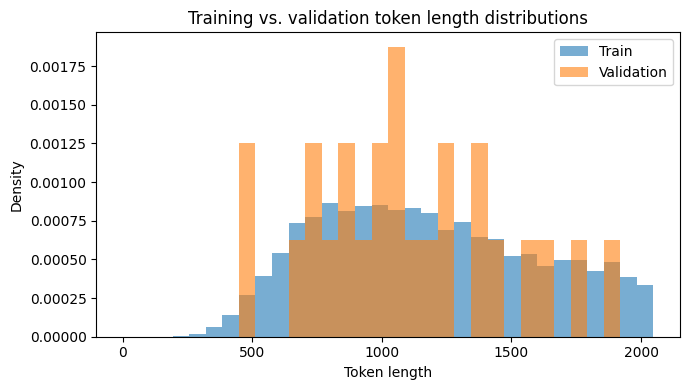

In [24]:
import matplotlib.pyplot as plt

train_lengths = [len(ex["token_ids"]) for ex in train_examples]
val_lengths = [len(ex["token_ids"]) for ex in val_examples]

# Normalize counts because the validation split is much smaller
bins = range(0, max(train_lengths + val_lengths) + 64, 64)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_lengths, bins=bins, density=True, alpha=0.6, label="Train")
ax.hist(val_lengths, bins=bins, density=True, alpha=0.6, label="Validation")
ax.set_xlabel("Token length")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


&nbsp;
## 8.5 加载预训练模型

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F11_raschka.webp" width=600>

In [22]:
import torch

from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import (
     load_model_and_tokenizer
)

device = get_device()

model, _ = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


&nbsp;
## 8.6 计算训练和验证损失

- 在本节中，我们将实现计算交叉熵损失的代码，该损失将用作蒸馏过程中的训练信号
- 训练期间我们也会将其应用于验证集进行评估
- 具有深度学习背景的读者可能已经熟悉分类问题中的交叉熵；此处使用的正是相同的交叉熵函数，其中预测目标是序列中的下一个词元
- 我们可以从第5章和第6章计算的对数概率推导出交叉熵损失

- 如第5章首次介绍对数概率计算时所述，该计算为下一个生成的词元赋予一个分数
- 较高的对数概率意味着模型为正确词元分配了更高的概率（预测更准确）；较低的对数概率则意味着概率较低（预测效果较差）
- 下图复用了第5章中的示例

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F12_raschka.webp" width=600>

- 与上图所示类似，第6章中的 `sequence_logprob` 函数计算每个 token 的对数概率（logprobs），然后返回它们的总和（即联合对数概率）。

- 让我们通过训练集中的一个例子来探讨这个问题；（为减少计算时间，我们选择最短的一个）：

In [23]:
# 5730 is the shortest example in train_examples
token_ids = train_examples[5730]["token_ids"]
prompt_len = train_examples[5730]["prompt_len"]

- 请注意，我们并未报告 `sequence_logprob` 返回的对数概率总和，而是将对数概率在答案标记数量上进行平均。答案标记数量可通过从总标记数中减去 `prompt_len` 来计算，总标记数包含提示和答案标记：

In [24]:
from reasoning_from_scratch.ch06 import sequence_logprob

tok = torch.tensor(token_ids, dtype=torch.long, device=device)

with torch.no_grad():
    seq_logprob = sequence_logprob(model, tok, prompt_len)
    num_answer_tokens = tok.numel() - prompt_len
    avg_logprob = -seq_logprob / num_answer_tokens
print(f"Average logprob: {avg_logprob:.2f}")

Average logprob: 1.68


- 我们可以使用 `cross_entropy` 函数进行相同计算
- 需要注意该函数是为分类任务设计的，除了模型的对数几率外，它还需要类标签作为参数；此处的类标签即"正确"的 token
- 具体而言，我们仅对答案 token 计算交叉熵（忽略提示 token）

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F13_raschka.webp" width=600 alt="图8.13">

In [25]:
input_ids = tok[:-1].unsqueeze(0)
target_ids = tok[1:]  # Targets are inputs shifted by one position
logits = model(input_ids).squeeze(0)

# Remove prompt tokens
first_answer_logit_idx = max(prompt_len - 1, 0)
answer_logits = logits[first_answer_logit_idx:]
answer_targets = target_ids[first_answer_logit_idx:]

with torch.no_grad():
    ce_mean_direct = torch.nn.functional.cross_entropy(
        answer_logits, answer_targets
    )
print(f"Cross-entropy: {ce_mean_direct:.2f}")

Cross-entropy: 1.68


- 如我们所见，当我们计算答案标记的平均对数概率时，结果与之前相同
- 换句话说，`cross_entropy` 函数内部实现了平均对数概率的计算
- 我们使用 `cross_entropy` 函数而非自定义的 `sequence_logprob` 函数，因为它针对更快训练进行了优化
- 让我们将其封装成一个方便调用的函数：

In [26]:
def compute_example_loss(model, example, device):
    token_ids = example["token_ids"]
    prompt_len = example["prompt_len"]

    input_ids = torch.tensor(
        token_ids[:-1], dtype=torch.long, device=device
    ).unsqueeze(0)
    target_ids = torch.tensor(
        token_ids[1:], dtype=torch.long, device=device
    )

    logits = model(input_ids).squeeze(0)

    answer_start = max(prompt_len - 1, 0)
    answer_logits = logits[answer_start:]
    answer_targets = target_ids[answer_start:]

    loss = torch.nn.functional.cross_entropy(
        answer_logits, answer_targets
    )
    return loss

In [27]:
with torch.no_grad():
    loss = compute_example_loss(
        model, train_examples[5730], device
    )

print(f"Loss: {loss:.2f}")

Loss: 1.68


- 需要注意的是，也可以并行计算多个样本，这被称为批处理（batching），但我们在此省略以降低资源需求
- 附录E讨论了批处理（batching）

- 我们还可以定义一个包装函数，用于在多个样本上计算损失：

In [28]:
@torch.no_grad()
def evaluate_examples(model, examples, device):
    was_training = model.training
    model.eval()
    total_loss = 0.0
    num_examples = 0

    for example in examples:
        loss = compute_example_loss(model, example, device)
        total_loss += loss.item()
        num_examples += 1

    if was_training:
        model.train()

    return total_loss / num_examples

In [29]:
train_loss = evaluate_examples(model, train_examples[:3], device)
print(f"Train loss (3 examples): {train_loss:.2f}")

Train loss (3 examples): 0.98


In [30]:
val_loss = evaluate_examples(model, val_examples[:3], device)
print(f"Validation loss (3 examples): {val_loss:.2f}")

Validation loss (3 examples): 1.02


- 我们将复用此函数来跟踪训练进度，以观察损失是否下降

&nbsp;
## 8.7 实现蒸馏的训练循环

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F14_raschka.webp" width=600 alt="图8.14">

- 训练循环与第6章几乎相同，除了我们现在会多次遍历训练集（epochs）并计算交叉熵损失而非GRPO损失

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F15_raschka.webp" width=500>

In [31]:
import time


def train_distillation(
    model,
    train_examples,
    val_examples,
    device,
    epochs=2,
    lr=5e-6,
    grad_clip_norm=None,
    seed=123,
    log_every=50,
    checkpoint_dir="checkpoints",
    csv_log_path=None,
):
    # Step 1: initialize optimizer (model is already loaded)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()

    total_steps = epochs * len(train_examples)
    global_step = 0
    rng = random.Random(seed)

    if csv_log_path is None:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        csv_log_path = f"train_distill_metrics_{timestamp}.csv"
    csv_log_path = Path(csv_log_path)

    # Step 2: iterate over training epochs
    for epoch in range(1, epochs + 1):
        # Step 3: shuffle the training examples at the start of the epoch
        epoch_examples = list(train_examples)
        rng.shuffle(epoch_examples)

        # Step 4: iterate over training examples in epoch
        for example in epoch_examples:
            global_step += 1

            # Stage 5: reset loss gradient
            # (it's best practice to do this at the beginning of each step)
            optimizer.zero_grad()

            # Step 6: compute the cross-entropy loss for the current example
            loss = compute_example_loss(model, example, device)

            # Step 7: backpropagate gradients
            loss.backward()

            # Optionally clip large gradients to improve training stability
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), grad_clip_norm
                )

            # Step 8: update the model weights
            optimizer.step()

            # Step 9: periodically evaluate the current model on the validation set
            if log_every and global_step % log_every == 0:
                val_loss = evaluate_examples(
                    model=model,
                    examples=val_examples,
                    device=device,
                )
                model.train()
                print(
                    f"[Epoch {epoch}/{epochs} "
                    f"Step {global_step}/{total_steps}] "
                    f"train_loss={loss.item():.4f} "
                    f"val_loss={val_loss:.4f}"
                )
                append_csv_metrics(
                    csv_log_path=csv_log_path,
                    epoch_idx=epoch,
                    total_steps=global_step,
                    train_loss=loss.item(),
                    val_loss=val_loss,
                )

        # Step 10: save a checkpoint for this epoch
        ckpt_path = save_checkpoint(
            model=model,
            checkpoint_dir=checkpoint_dir,
            step=global_step,
            suffix=f"epoch{epoch}",
        )
        print(f"Saved checkpoint to {ckpt_path}")
    return model


def save_checkpoint(model, checkpoint_dir, step, suffix=""):
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    suffix = f"-{suffix}" if suffix else ""
    ckpt_path = (
        checkpoint_dir /
        f"qwen3-0.6B-distill-step{step:05d}{suffix}.pth"
    )
    torch.save(model.state_dict(), ckpt_path)
    return ckpt_path


def append_csv_metrics(
    csv_log_path,
    epoch_idx,
    total_steps,
    train_loss,
    val_loss,
):
    if not csv_log_path.exists():
        csv_log_path.write_text(
            "epoch,total_steps,train_loss,val_loss\n",
            encoding="utf-8",
        )
    with csv_log_path.open("a", encoding="utf-8") as f:
        f.write(
            f"{epoch_idx},{total_steps},{train_loss:.6f},"
            f"{val_loss:.6f}\n"
        )

- 当序列长度为2048时，训练运行大约需要15 GB的RAM
- 为降低资源需求，您可以过滤掉较长的序列，例如在 `previous filtered_examples = filter_examples_by_max_len(examples, max_len=2048)` 步骤中，将 `max_len` 从 `2048` 改为 `1024` 或 `512`

In [32]:
torch.manual_seed(0)

train_distillation(
    model,
    train_examples=train_examples[:10],
    val_examples=val_examples[:10],
    device=device,
    epochs=2,
    lr=5e-6,
    grad_clip_norm=1.0,  # Same as in chapter 6
    seed=123,
    log_every=5,
    csv_log_path="train_distill_metrics.csv"
)

[Epoch 1/2 Step 5/20] train_loss=0.9648 val_loss=0.9082
[Epoch 1/2 Step 10/20] train_loss=0.9844 val_loss=0.8871
Saved checkpoint to checkpoints/qwen3-0.6B-distill-step00010-epoch1.pth
[Epoch 2/2 Step 15/20] train_loss=0.8008 val_loss=0.8707
[Epoch 2/2 Step 20/20] train_loss=0.7148 val_loss=0.8586
Saved checkpoint to checkpoints/qwen3-0.6B-distill-step00020-epoch2.pth


Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

- 上述运行仅为演示目的而简短
- 我们仅使用10个示例（`train_examples[:10]`）进行训练，并仅在10个验证示例（`val_examples`）上进行评估
- 对于实际训练，我们将其更改为 `train_examples` 和 `val_examples`

&nbsp;
## 8.8 评估蒸馏模型

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F16_raschka.webp" width=500>

- 我们可以下载以下便捷脚本，而非在此 notebook 中运行蒸馏训练

In [33]:
# from reasoning_from_scratch.ch07 import download_from_github

download_from_github(
    "ch08/04_train_with_distillation/distill.py"
)

distill.py: 12.9 KB (cached)


PosixPath('distill.py')

```bash
uv run distill.py \
--data_path deepseek-r1-math-train.json \
--validation_size 25 \
--epochs 3 \
--lr 1e-5 \
--max_seq_len 2048 \
--use_think_tokens \
--grad_clip 1.0
```

- 使用上述设置，在DGX Spark上使用15.02 GB GPU显存进行训练大约需要3小时05分钟
- 如果您不想自行运行，下文我们将下载生成的指标文件进行分析

In [34]:
download_from_github(
    "ch08/03_logs/deepseek-r1-2048_distill_metrics.csv"
)

deepseek-r1-2048_distill_metrics.csv: 10.3 KB (cached)


PosixPath('deepseek-r1-2048_distill_metrics.csv')

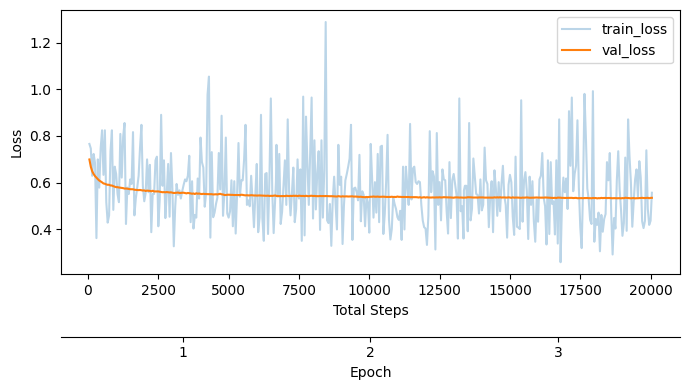

In [35]:
import csv
import matplotlib.pyplot as plt

def plot_distill_metrics(csv_path="train_distill_metrics.csv"):
    total_steps, train_losses, val_losses, epoch_bounds = [], [], [], {}

    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            step = int(row["total_steps"])
            epoch = int(row["epoch"])
            total_steps.append(step)
            train_losses.append(float(row["train_loss"]))
            val_losses.append(float(row["val_loss"]))
            epoch_bounds.setdefault(epoch, [step, step])[1] = step  # first/last step for each epoch

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(total_steps, train_losses, label="train_loss", alpha=0.3)
    ax.plot(total_steps, val_losses, label="val_loss")
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Loss")
    ax.legend()

    # Epoch axis
    epoch_axis = ax.secondary_xaxis("bottom")
    epoch_axis.spines["bottom"].set_position(("outward", 45))
    epochs = sorted(epoch_bounds)
    epoch_axis.set_xticks(
        [(epoch_bounds[epoch][0] + epoch_bounds[epoch][1]) / 2 
          for epoch in epochs]
    )
    epoch_axis.set_xticklabels(epochs)
    epoch_axis.set_xlabel("Epoch")

    plt.tight_layout()
    plt.show()

plot_distill_metrics("deepseek-r1-2048_distill_metrics.csv")

- 训练损失存在噪声，因为它基于单个样本计算
- 我们可以像验证损失那样在多个样本（例如25个）上运行评估，但这会增加训练时间
- 验证损失才是我们关注的重点；我们希望看到它持续下降
- 它会急剧下降，但随后停止取得显著进展
- 我们可以提高学习率以更激进地训练，但整体来看验证曲线表现良好

- 与第7章类似，我们可以使用第3章的评估工具来评估生成的模型检查点。

In [36]:
download_from_github(
    "ch03/02_math500-verifier-scripts/evaluate_math500.py"
)

evaluate_math500.py: 3.5 KB (cached)


PosixPath('evaluate_math500.py')

```bash
uv run evaluate_math500.py \
--dataset_size 500 \
--which_model reasoning \
--max_new_tokens 4096 \
--checkpoint_path run_11/checkpoints/distill/qwen3-0.6B-distill-step05746-epoch1.pth
```

|      | 教师数据                             | 轮次  | MATH-500准确率 | 最终验证损失 |
| ---- | ------------------------------------ | ----- | -------------- | ------------ |
| 1    | 基础模型（第3章）                    | -     | 15.2%          | -            |
| 2    | 推理模型（第3章）                    | -     | 48.2%          | -            |
| 3    | DeepSeek R1 蒸馏数据                 | 1     | 30.6%          | 0.5436       |
| 4    | DeepSeek R1 蒸馏数据                 | 2     | 32.4%          | 0.5349       |
| 5    | DeepSeek R1 蒸馏数据                 | 3     | 33.6%          | 0.5343       |
| 6    | Qwen3 235B A22B 蒸馏数据             | 1     | 45.0%          | 0.4043       |
| 7    | Qwen3 235B A22B 蒸馏数据             | 2     | 43.8%          | 0.3963       |
| 8    | Qwen3 235B A22B 蒸馏数据             | 3     | 44.2%          | 0.3948       |

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F18_raschka.webp" width=500>

&nbsp;
## 8.9 推理模型的未来方向

- 本节无代码
- 另请参阅附录A获取更多参考资料

&nbsp;
## 8.10 结论

本节无代码

- 希望您喜欢这本书！
- 我们已接近尾声，但还有更多“附录”章节可能对您有所帮助（涵盖大语言模型架构细节、以批处理模式运行代码以提高吞吐量、讨论不同的评估方法等）
- 此外，您可以在奖励材料 [#bonus-material](https://github.com/rasbt/reasoning-from-scratch?tab=readme-ov-file#bonus-material) 部分找到额外的奖励内容

- 我经常在 https://magazine.sebastianraschka.com 的博客上撰写关于人工智能和LLM主题的文章，你可能会觉得有用

&nbsp;
## 总结

- 本节无代码